# Overview

## Create the simulation

In [ ]:
from typing import Callable
from functools import partial
import numpy as np
from lucifex.fem import average_grid, cross_section_grid
from lucifex.fdm import GridFunctionSeries, NPyConstantSeries
from lucifex.io import write
from lucifex.sim import Simulation, run, xdmf_to_npz
from lucifex.plt import (
    plot_colormap, create_animation, plot_line, save_figure, plot_twin_lines,
    display_animation, get_ipynb_file_name, set_ipynb_variable, create_multifigure,
)
from lucifex.utils.fenicsx_utils import mesh_axes
from lucifex.utils.npy_utils import as_index, derivative
from crocodil.dns.system_a import dns_system_a, SYSTEM_A_REFERENCE
from crocodil.theory.system_a import (
    critical_saturation, mass_dissolved_asymptote, mass_capillary_asymptote,
    mass_dissolved_initial, mass_capillary_initial,
)
from crocodil.theory.grid_resolution import threshold_rayleigh

STORE = 1
WRITE = None
DIR_ROOT = f'./figures/{get_ipynb_file_name()}'
NX = set_ipynb_variable('NX', 60)
NY = set_ipynb_variable('NY', 60)
ANIM = set_ipynb_variable('ANIM', False)

simulation = dns_system_a(
    store_delta=STORE, 
    write_delta=WRITE, 
    dir_root=DIR_ROOT, 
    dir_uid=True,
)(
    Nx=NX,
    Ny=NY,
    scaling='advective',
    **SYSTEM_A_REFERENCE.replace(Ra=800.0),
    dt_max=0.1,
    dt_Cu=0.75,
    dt_Cd=0.75,
    dt_Cr=0.1,
    c_stabilization=None,
    c_limits=True,
    diagnostic=True,
)

Lx, Ly = simulation['Lx', 'Ly']
Ra, Da, epsilon, zeta0, sr, cr = (
    float(i) for i in simulation['Ra', 'Da', 'epsilon', 'zeta0', 'sr', 'cr']
)

Ra_thresh = threshold_rayleigh(Lx, Ly, NX, 2)
print(f"Ra = {Ra} , Ra_thresh = {Ra_thresh}")

sr_crit = critical_saturation(zeta0, cr, epsilon)
print(f'sr = {sr} , sr_crit = {sr_crit}')

save_fig = partial(save_figure, dir_path=simulation.dir_path, prefix=False)

posthook: Callable[[Simulation], None]
if WRITE: 
    posthook = partial(xdmf_to_npz, delete_xdmf=False)
else:
    posthook = lambda s: write(s.parameters, s.parameter_file, s.dir_path, mode='w')

Ra = 800.0 , Ra_thresh = 1350.0
sr = 0.2 , sr_crit = 0.10000000000000002


## Run the simulation

In [ ]:
n_stop = set_ipynb_variable('N_STOP', 200)
t_stop = 100.0
dt_init = 1e-6
n_init = 10

run(
    simulation, n_stop=n_stop, t_stop=t_stop, dt_init=dt_init, n_init=n_init, 
    posthook=posthook, show_progress=True,
)

s, c, psi, u = simulation['s', 'c', 'psi', 'u']
mC, mD, f = simulation['mC', 'mD', 'f']
fZeta0, fZetaPlus, fZetaMinus = f.split()

Environment variable `N_STOP=200`


  0%|          | 0/200 [00:00<?, ?it/s]

## Visualization

### Concentration

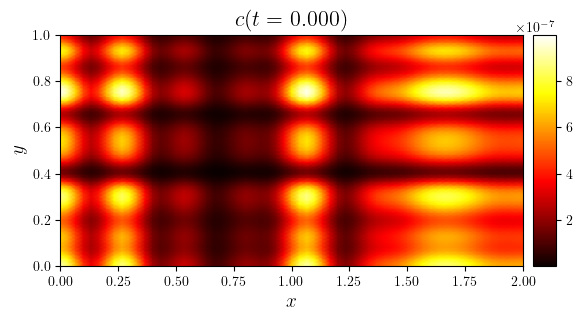

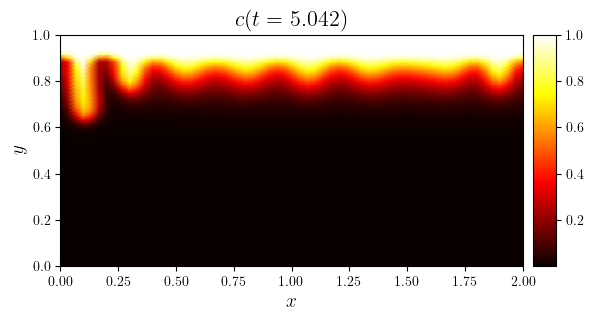

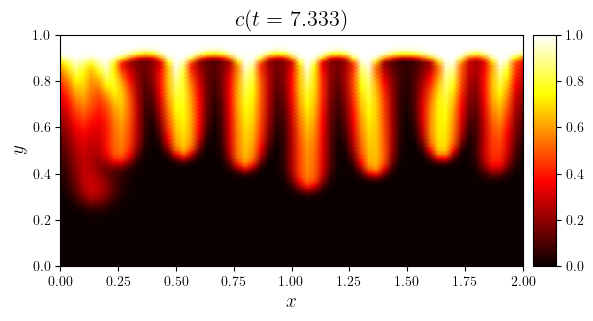

In [ ]:
_display = None
if not ANIM:
    time_indices = as_index(c.time_series, (0, 0.5, -1), fraction=True)
    for i in time_indices:
        fig, ax = plot_colormap(c.series[i], title=f'$c(t={c.time_series[i]:.3f})$')
else:
    time_slice = slice(0, None, 2)
    titles = [f'${c.name}(t={t:.3f})$' for t in c.time_series[time_slice]]
    anim = create_animation(
        plot_colormap,
        colorbar=False,
    )(c.series[time_slice], title=titles)
    anim_path = save_fig(f'{c.name}(t)', return_path=True)(anim)
    _display = display_animation(anim_path)
_display

### Saturation

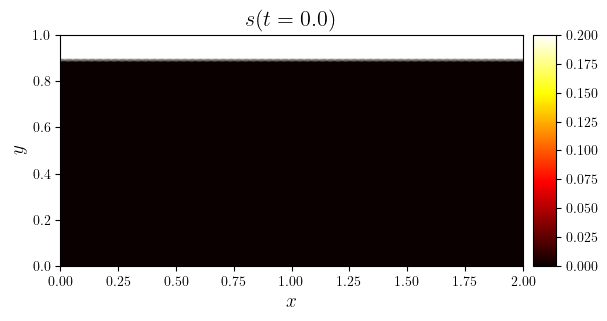

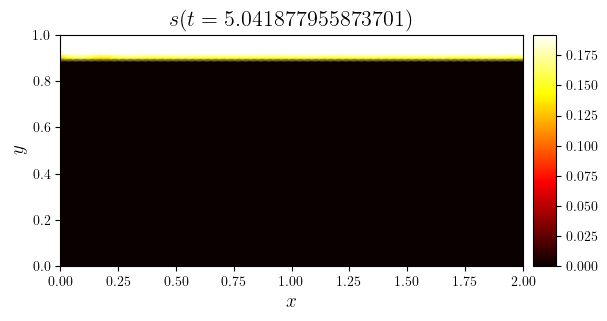

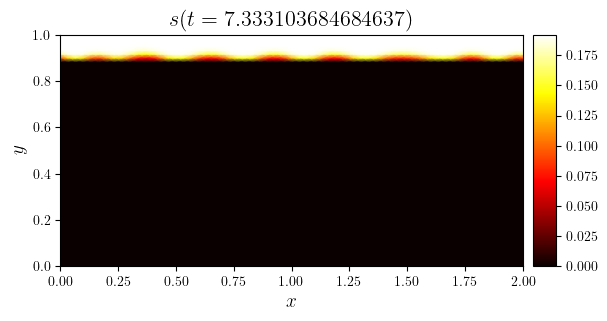

In [ ]:
_display = None
if not ANIM:
    time_indices = as_index(s.time_series, (0, 0.5, -1), fraction=True)
    for i in time_indices:
        fig, ax = plot_colormap(s.series[i], title=f'$s(t={s.time_series[i]})$')
else:
    time_slice = slice(0, None, 2)
    titles = [f'${s.name}(t={t:.3f})$' for t in s.time_series[time_slice]]
    anim = create_animation(
        plot_colormap,
        colorbar=(0, sr),
        y_lims=(zeta0 * Ly, Ly),
        aspect='auto',
    )(s.series[time_slice], title=titles)
    anim_path = save_fig(f'{s.name}(t)', return_path=True)(anim)
    _display = display_animation(anim_path)
_display

## Physical diagnostics

### Mass

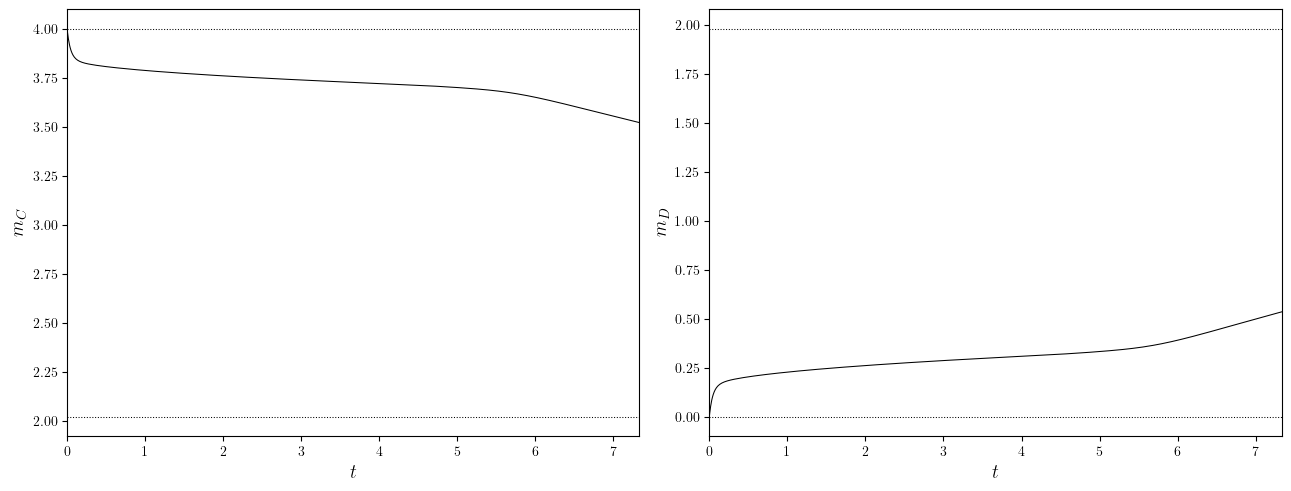

In [ ]:
mC_initial = mass_capillary_initial(epsilon, zeta0, sr, Lx, Ly)
mD_initial = mass_dissolved_initial(zeta0, sr, cr, Lx, Ly)
m_initial = mC_initial + mD_initial

mC_asymp = mass_capillary_asymptote(m_initial, epsilon, Lx, Ly)
mD_asymp = mass_dissolved_asymptote(m_initial, epsilon, Lx, Ly)

mfig, axs, _ = create_multifigure(n_cols=2)

plot_line(
    mfig, axs[0],
    (mC.time_series, mC.value_series),
    x_label='$t$',
    y_label='$m_C$',
)
axs[0].hlines(
    [mC_initial, mC_asymp], 
    0, max(mC.time_series), 
    linestyles='dotted', colors='black', linewidths=0.75,
)
plot_line(
    mfig, axs[1],
    (mD.time_series, mD.value_series),
    x_label='$t$',
    y_label='$m_D$'
)
axs[1].hlines(
    [mD_initial, mD_asymp], 
    0, max(mD.time_series), 
    linestyles='dotted', colors='black', linewidths=0.75,
)
save_fig('mCmD(t)')(mfig)

### Flux

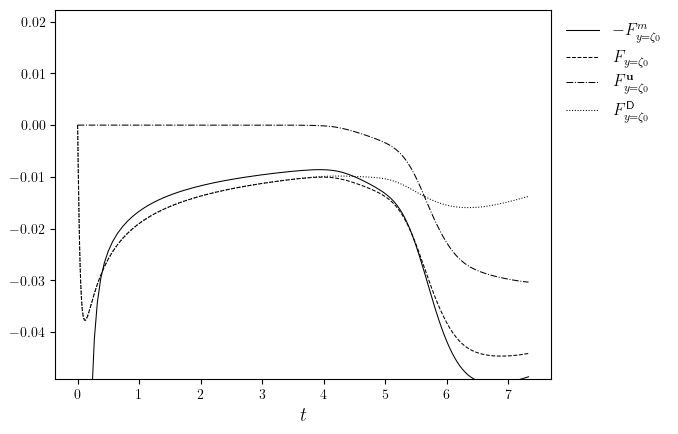

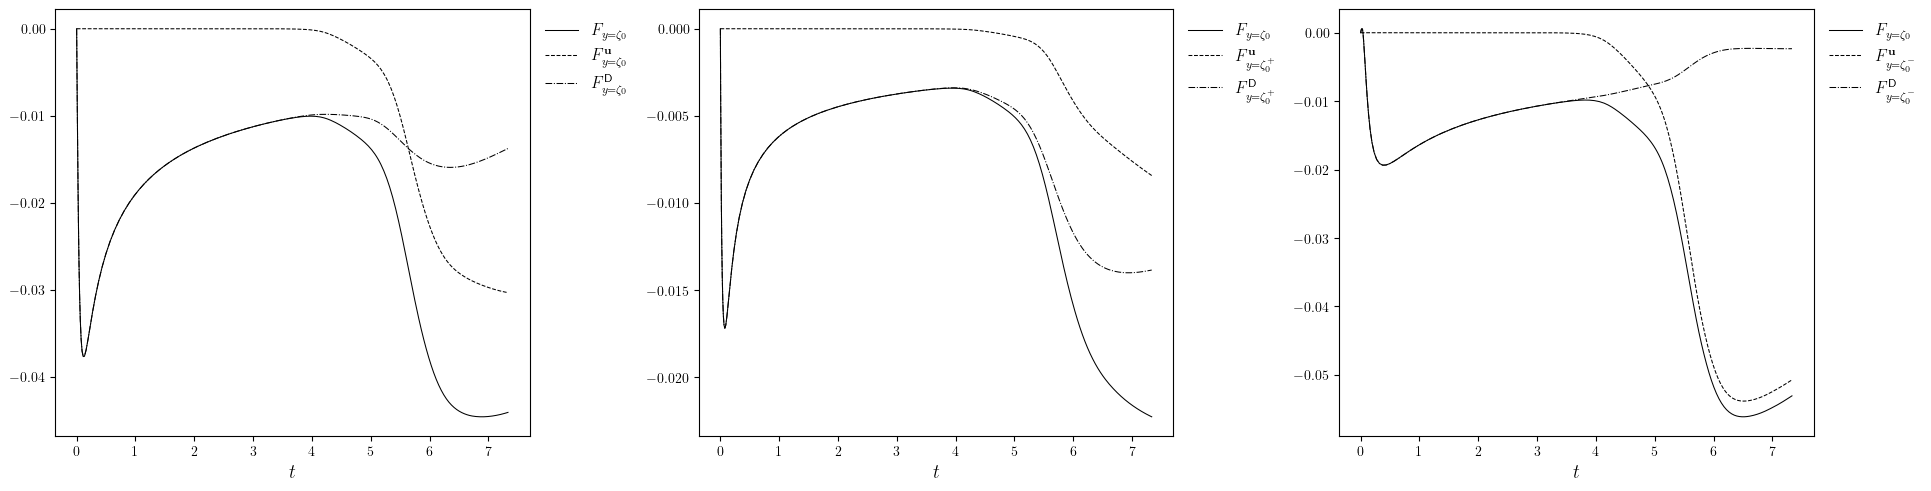

In [ ]:
fMass = -(1 / Lx) * derivative(mC.value_series, mC.time_series)
fZeta0Sum_series = [np.sum(i) for i in fZeta0.value_series]
f_lims = (min(fZeta0Sum_series), max(fZeta0Sum_series))
f_scale = max(*np.abs(f_lims))
y_lims = (f_lims[0] - 0.1 * f_scale, f_lims[1] + 0.5 * f_scale)

lines = [
    (mC.time_series, -fMass),
    (fZeta0.time_series, fZeta0Sum_series),
    (fZeta0.time_series, fZeta0.value_series),
]
legend_labels = [
    '$-F^m_{y=\zeta_0}$',
    '$F_{y=\zeta_0}$', 
    '$F^{\mathbf{u}}_{y=\zeta_0}$', 
    '$F^{\mathsf{D}}_{y=\zeta_0}$', 
]
fig, ax = plot_line(
    lines,
    cyc='black',
    x_label='$t$',
    legend_labels=legend_labels,
    y_lims=y_lims,
)
if np.max(fZeta0.time_series) > 50.0:
    ax.set_xscale('log')
save_fig(f'f(y=zeta0,t)')(fig)

superscripts = ('', '^+', '^-')
mfig, axs, _ = create_multifigure(n_cols=3)
for i, (flx, sup) in enumerate(zip((fZeta0, fZetaPlus, fZetaMinus), superscripts)):
    plot_line(
        mfig, axs[i],
        [
            (flx.time_series, [np.sum(i) for i in flx.value_series]),
            (flx.time_series, flx.value_series),
        ],
        x_label='$t$',
        # x_lims=fZeta0.time_series,
        legend_labels = [
            '$F_{y=\zeta_0}$', 
            '$F^{\mathbf{u}}_{y=\zeta_0*}$'.replace('*', sup), 
            '$F^{\mathsf{D}}_{y=\zeta_0*}$'.replace('*', sup), 
        ],
    )
save_fig(f'fMass(t)')(fig)

### Horizontal averages

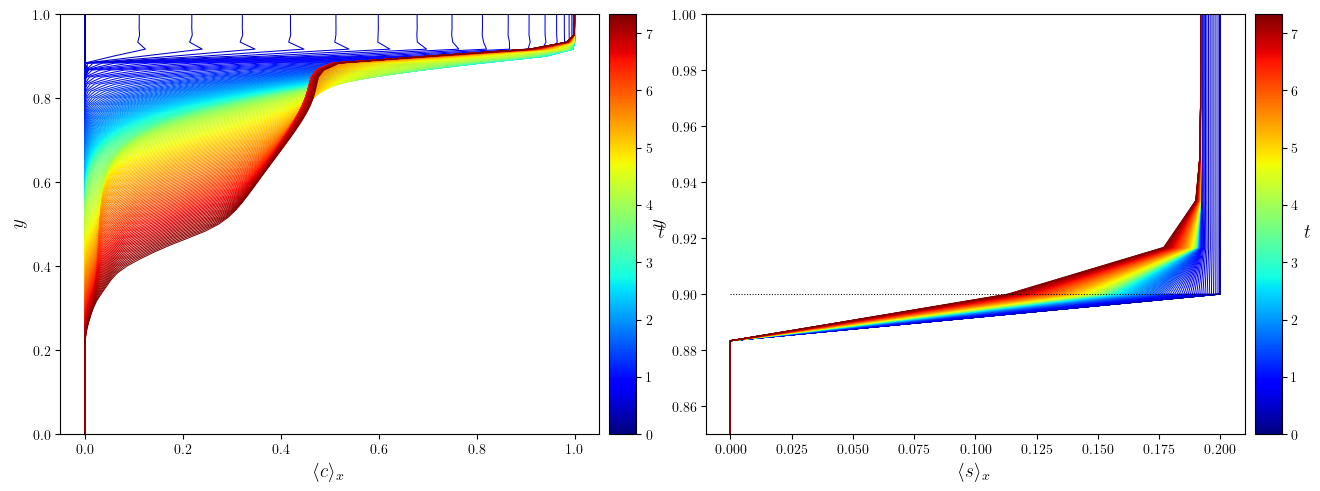

In [ ]:
sAvgX = GridFunctionSeries(average_grid(s.series, 'x'), s.time_series, 'sAvgX')
cAvgX = GridFunctionSeries(average_grid(c.series, 'x'), c.time_series, 'cAvgX')

mfig, axs, _ = create_multifigure(n_cols=2)

plot_line(
    mfig, axs[0],
    cAvgX.series, 
    cyc='jet',
    legend_title='$t$',
    legend_labels=(min(cAvgX.time_series), max(cAvgX.time_series)),
    x_label='$\langle c\\rangle_x$', 
    y_label='$y$',
    flip=True,
    y_lims=(0, Ly),
)

plot_line(
    mfig, axs[1],
    sAvgX.series, 
    cyc='jet',
    legend_title='$t$',
    legend_labels=(min(sAvgX.time_series), max(sAvgX.time_series)),
    x_label='$\langle s\\rangle_x$', 
    y_label='$y$',
    flip=True,
    y_lims=(zeta0 * Ly - 0.5 * (1 - zeta0) * Ly, Ly),
)
axs[1].hlines(zeta0 * Ly, 0, sr, linestyles='dotted', colors='black', linewidths=0.75)

save_fig('xAvgX(t)_sAvgX(t)')(fig)

### Subdomain averages

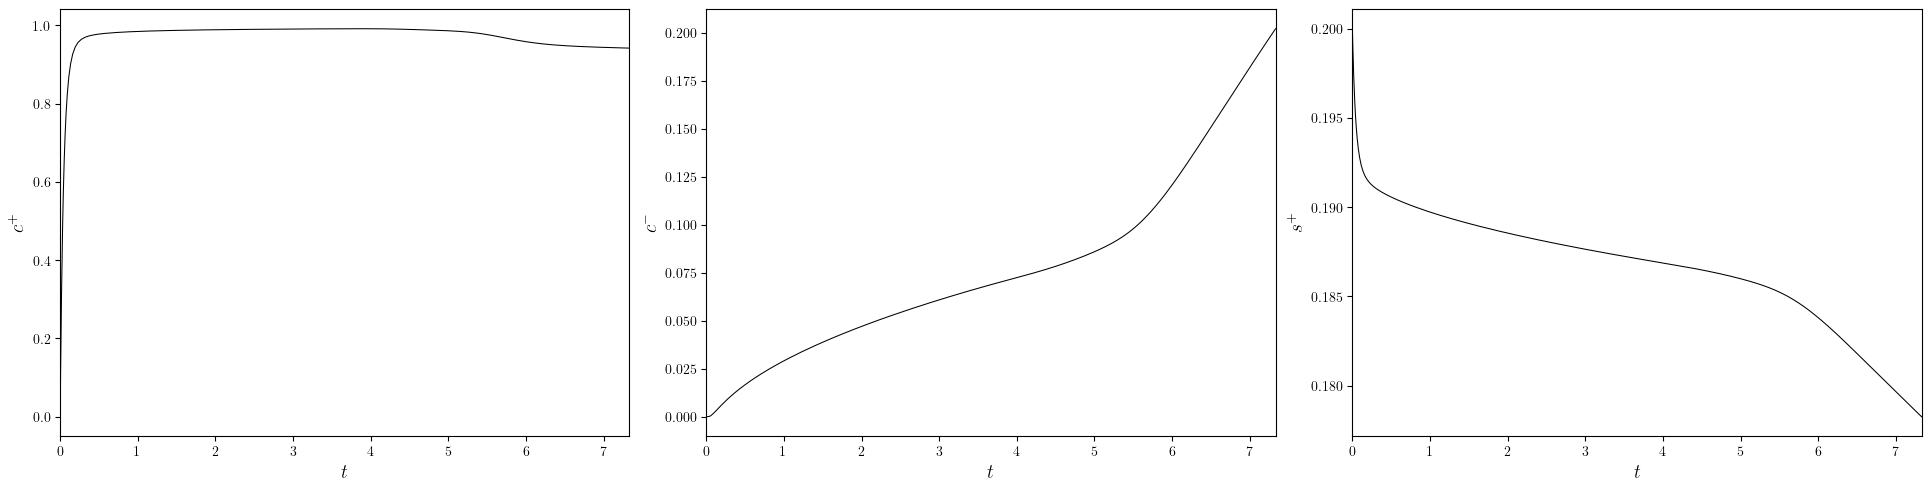

In [ ]:
y_axis = mesh_axes(use_cache=True)(c.mesh)[1]
zeta0_index = as_index(y_axis, zeta0)
slcPlus = slice(zeta0_index, None)
slcMinus = slice(0, zeta0_index)

cPlus = NPyConstantSeries(
    average_grid(c.series, ('x', 'y'), (':', slcPlus)), c.time_series, 'cPlus',
)
cMinus = NPyConstantSeries(
    average_grid(c.series, ('x', 'y'), (':', slcMinus)), c.time_series, 'cMinus',
)
sPlus = NPyConstantSeries(
    average_grid(s.series, ('x', 'y'), (':', slcPlus)), s.time_series, 'sPlus',
)

mfig, axs, _ = create_multifigure(n_cols=3)

plot_line(
    mfig, axs[0],
    (cPlus.time_series, cPlus.value_series),
    x_label='$t$',
    y_label='$c^+$',
)

plot_line(
    mfig, axs[1],
    (cMinus.time_series, cMinus.value_series),
    x_label='$t$',
    y_label='$c^-$',
)

plot_line(
    mfig, axs[2],
    (sPlus.time_series, sPlus.value_series),
    x_label='$t$',
    y_label='$s^+$',
)
save_fig('cPlus(t)_cMinus(t)_sPlus(t)')(mfig)

### Correlation

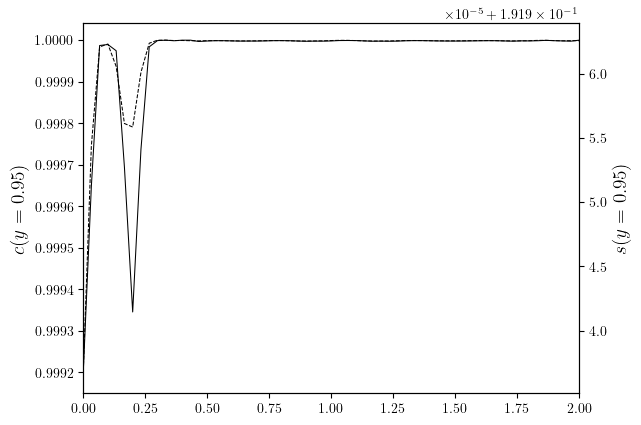

In [ ]:
time_index = int(0.5 * n_stop)
y_cs_target = 0.95
cx, y_cs = cross_section_grid(c.series[time_index], 'y', y_cs_target)
sx, y_cs = cross_section_grid(s.series[time_index], 'y', y_cs_target)

fig, ax = plot_twin_lines(
    (cx, sx),
    twin_labels=(f'$c(y={y_cs})$', f'$s(y={y_cs})$')
)

### Velocity norms

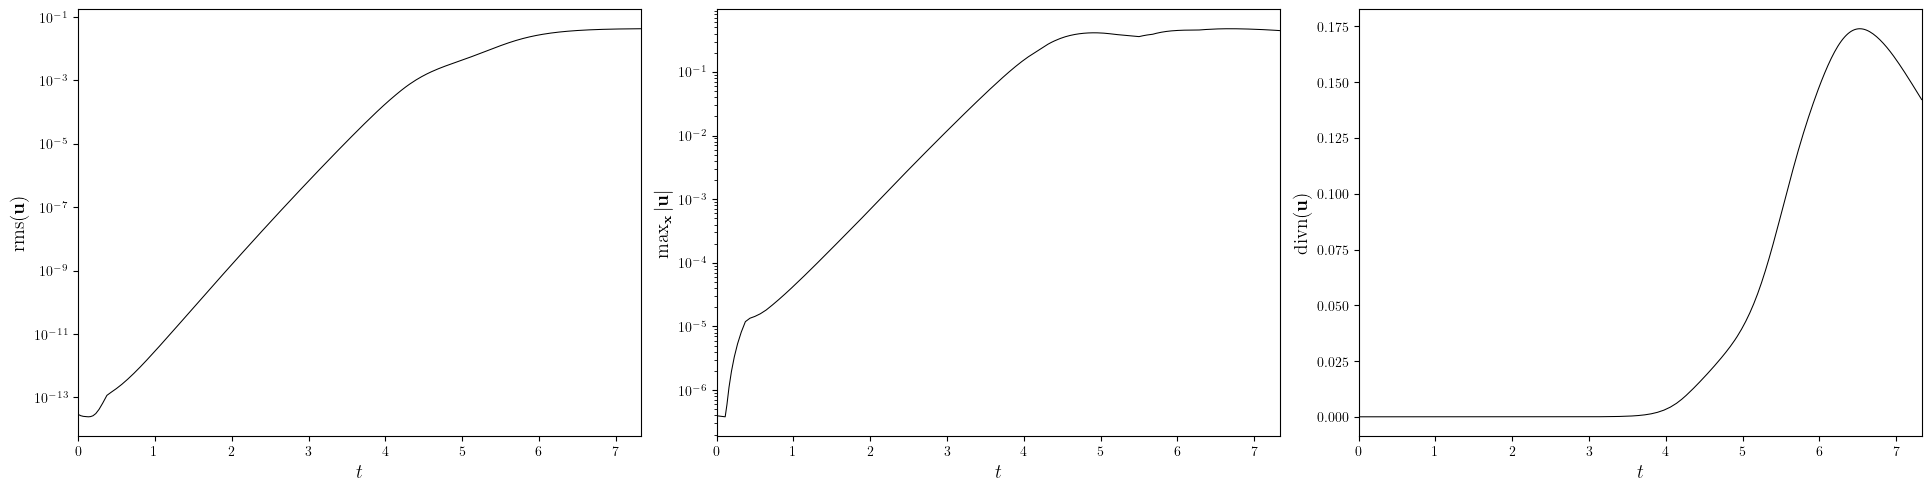

In [ ]:
uRMS, uMinMax, uDiv = simulation['uRMS', 'uMinMax', 'uDiv']
uMax = uMinMax.sub(1)

mfig, axs, _ = create_multifigure(n_cols=3)

plot_line(
    mfig, axs[0],
    (uRMS.time_series, uRMS.value_series),
    x_label='$t$',
    y_label='$\mathrm{rms}(\mathbf{u})$',
)
axs[0].set_yscale('log')

plot_line(
    mfig, axs[1],
    (uMax.time_series, uMax.value_series),
    x_label='$t$',
    y_label='$\max_{\mathbf{x}}|\mathbf{u}|$',
)
axs[1].set_yscale('log')

plot_line(
    mfig, axs[2],
    (uDiv.time_series, uDiv.value_series),
    x_label='$t$',
    y_label='$\mathrm{divn}(\mathbf{u})$',
)

save_fig('uRMS(t)_uMax(t)_uDiv(t)')(mfig)

## Numerical diagnostics

### Timestep contraints

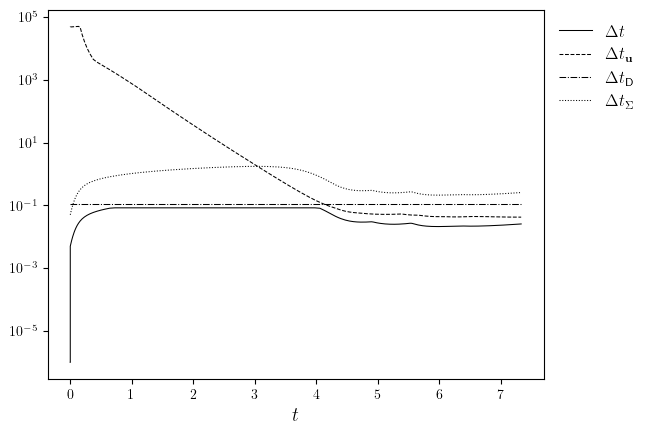

In [ ]:
dt, dtU, dtD, dtSigma = simulation['dt', 'dtU', 'dtD', 'dtSigma']

fig, ax = plot_line(
    [
        (dt.time_series, dt.value_series), 
        (dtU.time_series, dtU.value_series), 
        (dtD.time_series, dtD.value_series), 
        (dtSigma.time_series, dtSigma.value_series),
    ],
    x_label='$t$',
    legend_labels=['$\Delta t$', '$\Delta t_{\mathbf{u}}$', '$\Delta t_{\mathsf{D}}$', '$\Delta t_{\Sigma}$'],
)
ax.set_yscale('log')
save_fig('dt(t)')(fig)

### Concentration limits

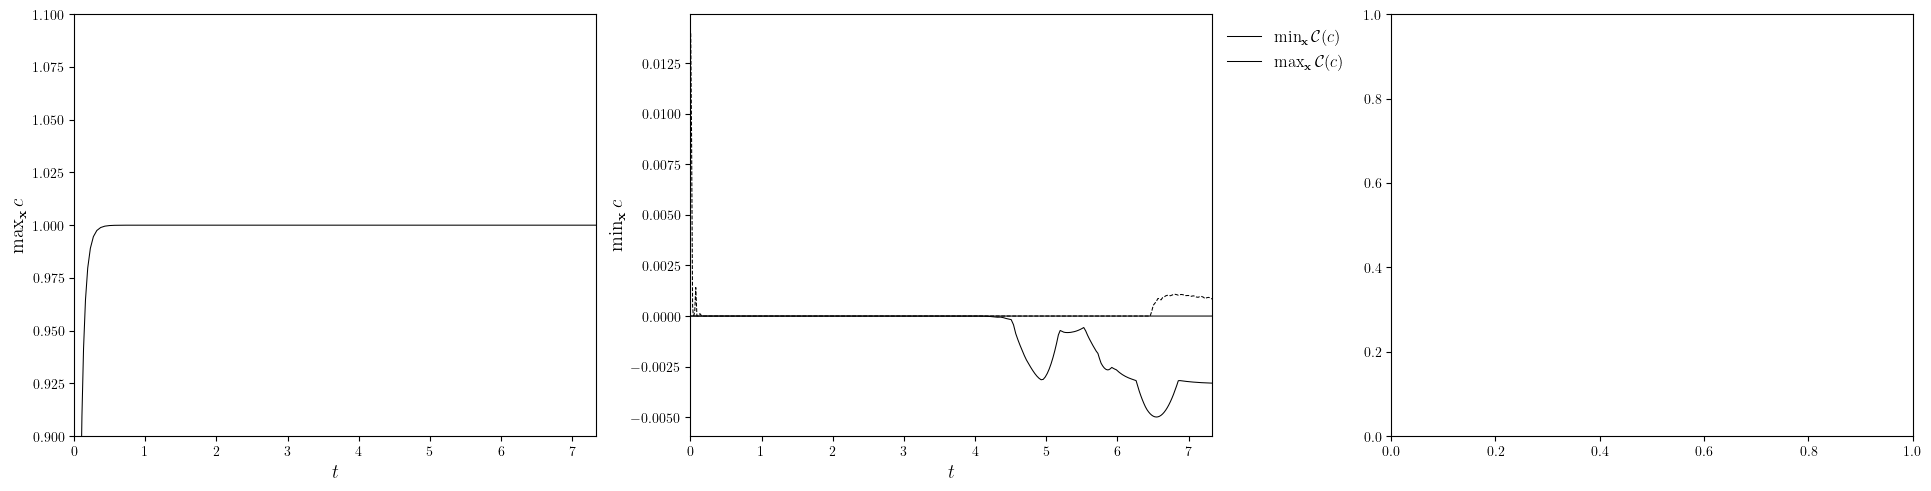

In [ ]:
cMinMax = simulation['cMinMax']
cMin, cMax = cMinMax.split()

n_cols = 3 if 'cCorr' in simulation.namespace else 2
mfig, axs, _ = create_multifigure(n_cols=n_cols)

plot_line(
    mfig, axs[0],
    (cMax.time_series, cMax.value_series),
    x_label='$t$',
    y_label='$\max_{\mathbf{x}}c$',
    y_lims=(1-0.1, 1+0.1),
)

plot_line(
    mfig, axs[1],
    (cMin.time_series, cMin.value_series),
    x_label='$t$',
    y_label='$\min_{\mathbf{x}}c$',
)

if n_cols == 3:
    cCorr = simulation['cCorr']
    plot_line(
        mfig, axs[1],
        [
            (cCorr.time_series, [np.min(i) for i in cCorr.dofs_series]),
            (cCorr.time_series, [np.max(i) for i in cCorr.dofs_series]),
        ],
        x_label='$t$',
        legend_labels=['$\min_{\mathbf{x}}\mathcal{C}(c)$', '$\max_{\mathbf{x}}\mathcal{C}(c)$'],
    )

save_fig('cMin(t)_cMax(t)')(fig)

### Mass conservation

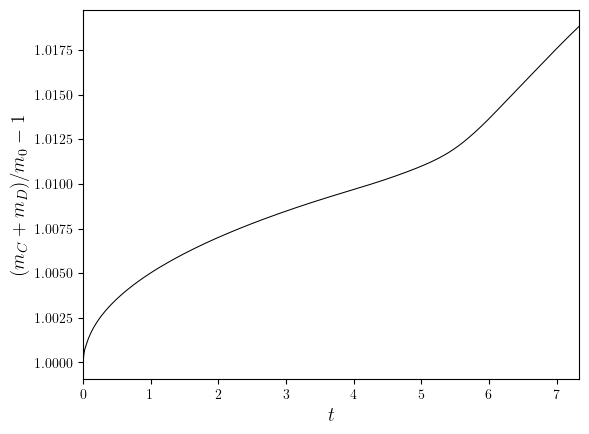

In [ ]:
m_sum = np.array([i + j for i, j in zip(mC.value_series, mD.value_series)]) - 1

fig, ax = plot_line(
    (mC.time_series, m_sum / m_sum[0]),
    x_label='$t$',
    y_label='$(m_C + m_D)/m_0 - 1$'
)
save_figure('m(t)_normalized', simulation.dir_path, prefix=False)(fig)

### Thumbnail image

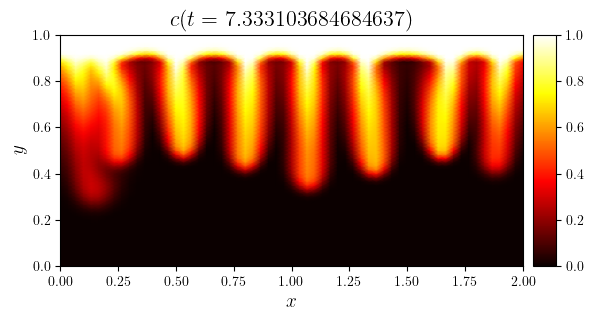

In [ ]:
time_index = -1
fig, ax = plot_colormap(c.series[time_index], title=f'$c(t={c.time_series[time_index]})$')
save_figure('thumbnail', DIR_ROOT, prefix=False)(fig, file_ext='png')